In [32]:
import numpy as np
import pandas as pd

class DJEnvironment:
    """
    RL Environment for DJ track selection.
    State  : normalized audio features of the current track [bpm, energy, danceability]
    Action : index of the next track to play (discrete)
    Reward : energy + danceability of next track - |ΔBPM| / 60  (transition penalty)
    """
    FEATURE_COLS = ["bpm", "energy", "danceability"]

    def __init__(self, track_df: pd.DataFrame, max_steps: int = 20):
        self.tracks    = track_df[["song", "dj"] + self.FEATURE_COLS].dropna().reset_index(drop=True)
        self.max_steps = max_steps
        self._normalize()
        self.current_idx = 0
        self.step_count  = 0

    def _normalize(self):
        for col in self.FEATURE_COLS:
            lo, hi = self.tracks[col].min(), self.tracks[col].max()
            self.tracks[f"{col}_norm"] = (self.tracks[col] - lo) / (hi - lo + 1e-8)
        self.norm_cols = [f"{c}_norm" for c in self.FEATURE_COLS]

    def _state(self):
        return self.tracks.loc[self.current_idx, self.norm_cols].values.astype(np.float32)

    def reset(self):
        self.current_idx = np.random.randint(len(self.tracks))
        self.step_count  = 0
        return self._state()

    def step(self, action: int):
        current = self.tracks.iloc[self.current_idx]
        nxt     = self.tracks.iloc[action]

        bpm_diff = abs(nxt["bpm"] - current["bpm"]) / 60.0
        reward   = nxt["energy_norm"] + nxt["danceability_norm"] - bpm_diff

        self.current_idx = action
        self.step_count += 1
        done = self.step_count >= self.max_steps
        # README: Penalty to avoid repetition
        if action == self.current_idx:
            reward -= 100  # penalize picking the same track

    def reset(self):
        self.current_idx = np.random.randint(len(self.tracks))
        self.step_count  = 0
        self.played      = {self.current_idx}   # ← track history
        return self._state()

    def step(self, action: int):
        current  = self.tracks.iloc[self.current_idx]
        nxt      = self.tracks.iloc[action]
        bpm_diff = abs(nxt["bpm"] - current["bpm"]) / 60.0
        reward   = nxt["energy_norm"] + nxt["danceability_norm"] - bpm_diff
        # Hard penalty for repeating a track
        if action in self.played:
            reward -= 5.0
        self.played.add(action)
        self.current_idx = action
        self.step_count += 1
        done = self.step_count >= self.max_steps
        return self._state(), reward, done

    @property
    def n_actions(self): return len(self.tracks)

    @property
    def state_size(self): return len(self.norm_cols)


In [29]:
class QLearningAgent:
    """Linear Q-learning: Q(s, a) = W[a] · s"""

    def __init__(self, state_size, n_actions,
                 lr=0.01, gamma=0.95, epsilon=1.0,
                 epsilon_decay=0.995, epsilon_min=0.05):
        self.n_actions     = n_actions
        self.lr            = lr
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        self.W             = np.zeros((n_actions, state_size))

    def q_values(self, state):
        return self.W @ state

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_values(state)))

    def update(self, state, action, reward, next_state, done):
        q_curr   = self.q_values(state)[action]
        q_next   = 0.0 if done else np.max(self.q_values(next_state))
        td_error = reward + self.gamma * q_next - q_curr
        self.W[action] += self.lr * td_error * state
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


Ep    0 | reward: -34.642 | ε: 0.905
Ep  100 | reward: -54.791 | ε: 0.050
Ep  200 | reward: -32.711 | ε: 0.050
Ep  300 | reward: -46.494 | ε: 0.050
Ep  400 | reward: -71.238 | ε: 0.050


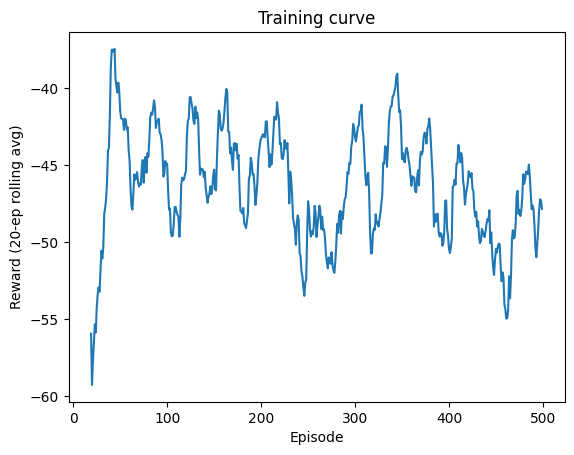

In [30]:
audio_features_df = pd.read_csv("audio_features_df.csv")
env   = DJEnvironment(audio_features_df, max_steps=20)
agent = QLearningAgent(state_size=env.state_size, n_actions=env.n_actions)

N_EPISODES = 500
reward_log = []

for ep in range(N_EPISODES):
    state        = env.reset()
    total_reward = 0.0
    done         = False

    while not done:
        action                   = agent.select_action(state)
        next_state, reward, done = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state        = next_state
        total_reward += reward

    reward_log.append(total_reward)
    if ep % 100 == 0:
        print(f"Ep {ep:4d} | reward: {total_reward:.3f} | ε: {agent.epsilon:.3f}")

import matplotlib.pyplot as plt
plt.plot(pd.Series(reward_log).rolling(20).mean())
plt.xlabel("Episode"); plt.ylabel("Reward (20-ep rolling avg)")
plt.title("Training curve"); plt.show()


In [31]:
state   = env.reset()
played  = {env.current_idx}

for _ in range(20):
    q_vals = agent.q_values(state).copy()
    q_vals[list(played)] = -np.inf          # ← mask already-played tracks
    action = int(np.argmax(q_vals))

    state, _, done = env.step(action)
    played.add(action)
    row = env.tracks.iloc[env.current_idx]
    print(f"→ {row['song']:<55} | BPM: {row['bpm']:.0f}  energy: {row['energy_norm']:.2f}  dance: {row['danceability_norm']:.2f}")
    if done: break


→ Luciid - Green Street (unreleased)                      | BPM: 157  energy: 0.07  dance: 0.39
→ HDMIRROR - ANTHEM                                       | BPM: 80  energy: 0.07  dance: 0.33
→ Freak Dub - Randomer                                    | BPM: 125  energy: 0.23  dance: 0.48
→ Underworld - Rez                                        | BPM: 135  energy: 0.16  dance: 0.54
→ Buga - Hands-Up!                                        | BPM: 80  energy: 0.13  dance: 0.45
→ Pegassi - Yoyoyo                                        | BPM: 152  energy: 0.19  dance: 0.44
→ Topper top - Sir Spyro (mixed in with something)        | BPM: 71  energy: 0.14  dance: 0.47
→ Fred again.. & Romy & HAAi - Lights Out w/ Fred again.. & Romy & HAAi - Lights Out (DnB Edit) | BPM: 134  energy: 0.48  dance: 0.47
→ Fred again.. - Tanya (Maybe Life)                       | BPM: 133  energy: 0.29  dance: 0.54
→ Wii                                                     | BPM: 131  energy: 0.13  dance: 0.42
→ Viz